In [40]:
import os
import librosa
import numpy as np
import joblib
from hmmlearn import hmm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Path to your dataset
DATASET_PATH = os.path.join('..', 'DATASET')

# -----------------------------------------------------------------------------
# 1. Feature Extraction (Modified for HMM)
# -----------------------------------------------------------------------------
def extract_mfcc_sequence(file_path):
    """
    Extracts MFCC sequence. 
    Unlike SVM, we do NOT average the features. We keep the time dimension.
    Returns: Array of shape (Time_Steps, 13)
    """
    try:
        # Load audio (16kHz standard)
        audio, sr = librosa.load(file_path, sr=16000)
        # Trim silence
        audio, _ = librosa.effects.trim(audio)
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        # Transpose so rows=time, cols=features (Required for HMM)
        return mfccs.T
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None
    
# -----------------------------------------------------------------------------
# 2. Data Loading & Organization
# -----------------------------------------------------------------------------
data = {} # Dictionary to store features for each digit: {0: [arr1, arr2...], 1: [...]}

if not os.path.exists(DATASET_PATH):
    print("Error: DATASET path not found.")
else:
    print("Loading and extracting features...")
    for speaker in os.listdir(DATASET_PATH):
        speaker_path = os.path.join(DATASET_PATH, speaker)
        if os.path.isdir(speaker_path):
            for digit in os.listdir(speaker_path):
                digit_path = os.path.join(speaker_path, digit)
                if os.path.isdir(digit_path):
                    if int(digit) not in data: 
                        data[int(digit)] = []
                    
                    for audio_file in os.listdir(digit_path):
                        if audio_file.endswith('.wav'):
                            feat = extract_mfcc_sequence(os.path.join(digit_path, audio_file))
                            if feat is not None:
                                data[int(digit)].append(feat)

Loading and extracting features...
length of data: 10


In [77]:
# Summary of loaded data
print("length of data:", len(data))

# Sum the length of the lists inside the dictionary values
total_files = sum(len(files) for files in data.values())
print(f"Total audio files loaded: {total_files}")

length of data: 10
Total audio files loaded: 1594


In [42]:
# -----------------------------------------------------------------------------
# 3. Training the HMMs (One separate model per Digit)
# -----------------------------------------------------------------------------
hmm_models = {}

# Split data and Train
X_test_all = []
y_test_all = []

print("Training HMM models...")
for digit, features_list in data.items():
    # Split this digit's data into train/test
    train_list, test_list = train_test_split(features_list, test_size=0.2, random_state=42)
    
    # Save test data for later evaluation
    X_test_all.extend(test_list)
    y_test_all.extend([digit] * len(test_list))
    
    # PREPARE DATA FOR HMM:
    # hmmlearn needs all sequences concatenated into one long matrix (X)
    # and a list of lengths so it knows where one file ends and the next begins.
    X_train = np.concatenate(train_list)
    lengths = [len(x) for x in train_list] 
    
    # Define the HMM
    # n_components=5 means 5 states (e.g., Start -> S-sound -> V-sound -> N-sound -> End)
    # n_mix=3 means 3 Gaussians per state to model voice variability
    model = hmm.GMMHMM(n_components=5, n_mix=7, covariance_type='diag', n_iter=100)
    
    # Train (Fit)
    model.fit(X_train, lengths)
    hmm_models[digit] = model
    print(f" - Model for digit '{digit}' trained.")

Training HMM models...
 - Model for digit '0' trained.
 - Model for digit '1' trained.
 - Model for digit '2' trained.
 - Model for digit '3' trained.
 - Model for digit '4' trained.
 - Model for digit '5' trained.
 - Model for digit '6' trained.
 - Model for digit '7' trained.
 - Model for digit '8' trained.
 - Model for digit '9' trained.


In [43]:
# -----------------------------------------------------------------------------
# 4. Evaluation (The Viterbi Competition)
# -----------------------------------------------------------------------------
y_pred = []

print("\nEvaluating...")
for sequence in X_test_all:
    best_score = float('-inf')
    best_digit = -1
    
    # Score this sequence against ALL 10 models
    for digit, model in hmm_models.items():
        try:
            # score() returns the Log-Likelihood (how probable is this sequence?)
            score = model.score(sequence)
            if score > best_score:
                best_score = score
                best_digit = digit
        except:
            continue
            
    y_pred.append(best_digit)

# Calculate Accuracy
acc = accuracy_score(y_test_all, y_pred)
print(f"\nHMM Accuracy: {acc*100:.2f}%")

Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance



Evaluating...


Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate


HMM Accuracy: 85.36%


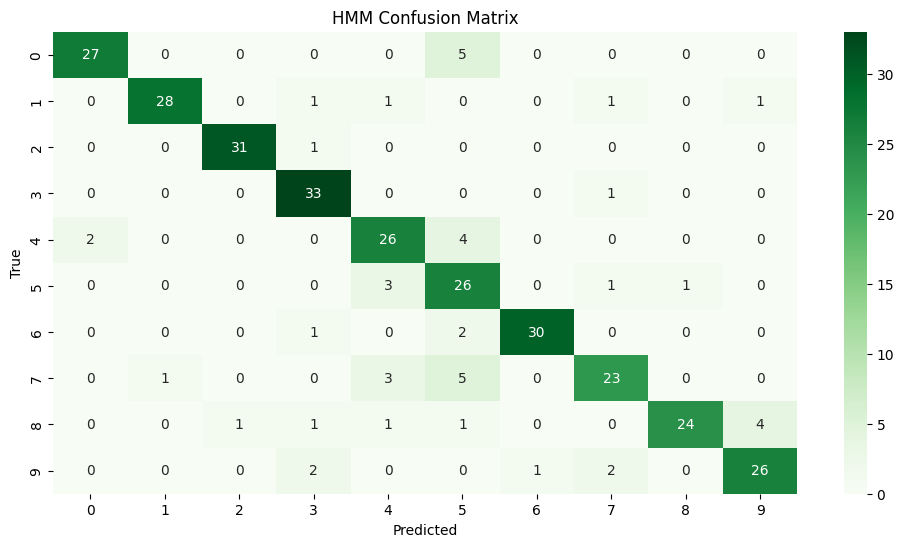

In [78]:
# -----------------------------------------------------------------------------
# 5. Visualization
# -----------------------------------------------------------------------------
cm = confusion_matrix(y_test_all, y_pred)
plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=sorted(data.keys()), yticklabels=sorted(data.keys()))
plt.title('HMM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# -----------------------------------------------------------------------------
# 6. Inference Function (Test a specific file)
# -----------------------------------------------------------------------------
def predict_digit_hmm(file_path):
    feat = extract_mfcc_sequence(file_path)
    if feat is None: return "Error"
    
    scores = {}
    for digit, model in hmm_models.items():
        scores[digit] = model.score(feat)
    
    # Return the digit with the highest score
    return max(scores, key=scores.get)

# predict a specific file
prediction = predict_digit_hmm(f"{DATASET_PATH}/Mohammed ESSALHI/0/R-10.wav")
print(prediction)

Degenerate mixture covariance
Degenerate mixture covariance


0
